<div style="border-radius:10px; font-size:100%; padding:10px; color:#ffffff; background-color:#6827F5">

<h1 align="center"><font color="#ffffff">Welcome to Hypothesis Testing and Predictive Modelling on Essay Scoring Data.</font></h1>

1. In this Notebook I will going to perform efficient feature engineering on **Essay Scoring** dataset with the help of **Polars** and **Regex**.
2. Then I will going to perform **Hypothesis Testing** on some key selected columns and will present their **Effect Size** for real world application.
4. After that I will perform **Predictive Modelling** with some **Linear models, SVM** and after that **Multi Layer Perceptron**.
5. **Quadratic Weighted Kappa (QWK)** also known as **Cohen Kappa** will be used to evaluate created models.
6. Then I will try **Thresholds optimization** technique to see whether it can help us optimizing model's prediction even further.

<div style="border-radius:10px; font-size:100%; padding:10px; color:#ffffff; background-color:#6827F5">

<h1 align="center"><font color="#ffffff">1. Importing Libraries and Loading Data</font></h1>
<a id="1"></a>

In [1]:
# importing required libraries

import time
import pandas as pd
import polars as pl
import numpy as np
import regex as re
import string
from sklearn.feature_extraction.text import CountVectorizer #TfidfVectorizer,
from scipy.sparse import coo_matrix, hstack
import pickle
import lightgbm as lgbm
import warnings 
from scipy.stats import ttest_rel, ttest_ind, levene, shapiro, f_oneway, mannwhitneyu, kruskal, anderson
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

In [2]:
# Loading dataset
train = pl.read_csv("/kaggle/input/competitions/learning-agency-lab-automated-essay-scoring-2/train.csv")

In [3]:
train.head()

essay_id,full_text,score
str,str,i64
"""000d118""","""Many people have car where the…",3
"""000fe60""","""I am a scientist at NASA that …",3
"""001ab80""","""People always wish they had th…",4
"""001bdc0""","""We all heard about Venus, the …",4
"""002ba53""","""Dear, State Senator This is a…",3


<div style="border-radius:10px; font-size:100%; padding:10px; color:#ffffff; background-color:#6827F5">

<h1 align="center"><font color="#ffffff">2. Preprocessing and Utility Functions</font></h1>
<a id="2"></a>
Now I will creae some Utility and Preprocessing functions with help of which I will perform **Data Munging** and get relevant information out our our **Essay Scoring Dataset**.

In [4]:
# al contains all Correct words in a Set, which will be used for fiding Incorrect words

al = pickle.load(open("/kaggle/input/datasets/gursewak1/lgbm-v36/Correct_Words_Set/Correct_Words_Set.pkl", "rb"))

def remove__(x):
    """Removes multiple spaces"""
    return re.sub(r"\s{2,100000}", "", x) 


def return_len(x): 
    return len(x)


def clean_row_for_split(row):
    """Preprocessing required to split the words"""
    row = row.lower()
    row = re.sub(r"[\<\>\|\^\@\*²¹©\$\d\&,\/\.\(\)\[\]\&\%\#\!\-\_\=\+\:\?\"';]"," ", row)
    row = re.sub(r"\s{2,10000}", " ", row)
    row = row.split(" ")
    return row


def wordsAndError(x): 
    splitted = clean_row_for_split(x) 
    n = len(splitted)
    uni = Unique_words_prcnt(splitted)
    err = Spelling_Errors(splitted) 
    return (n, int(n * uni), uni, err)
    

def Spelling_Errors(row):
    """Returns spelling errors as percentage of total words"""
    num = 0
    nn = len(row)
    for tok in row:
        if tok not in al:
            num+=1

    return num/nn


def Unique_words_prcnt(row):
    """Returns Percentage of unique words"""
    return len(set(row))/len(row)

In [5]:
# Cleaning Full_text column which will be used to generate features

train = train.with_columns(pl.col("full_text").map_elements(remove__).alias("text_cln"))

pl_cols = [
    pl.col("text_cln").map_elements(return_len).alias("text_len"),
    pl.col("text_cln").map_elements(wordsAndError, return_dtype = pl.Object).alias("wordsUniError")
]

train = train.with_columns(pl_cols)

word_cols = [
    pl.col("wordsUniError").map_elements(lambda x: x[0], return_dtype = int).alias("total_words"), 
    pl.col("wordsUniError").map_elements(lambda x: x[1], return_dtype = int).alias("unique_words"), 
    pl.col("wordsUniError").map_elements(lambda x: x[2]*100, return_dtype = float).alias("unique_words%"), 
    pl.col("wordsUniError").map_elements(lambda x: x[3]*100, return_dtype = float).alias("error%"), 
]

train = train.with_columns(word_cols).drop("wordsUniError") 

In [6]:
def parasStats(x): 
    l = [] 
    for i in x: 
        l.append(len(i)) 
    return np.mean(l), np.median(l), np.max(l), np.min(l)

def getParasWordsStats(x):
    cnt, wrds, errPerc = [], [], []
    for para in x:
        s = wordsAndError(para)
        cnt.append(s[0])
        wrds.append(s[1])
        errPerc.append(s[3]) 
    
    return (
        np.mean(cnt), np.max(cnt), np.min(cnt),
        np.mean(wrds), np.max(wrds), np.min(wrds),
        np.mean(errPerc), np.max(errPerc), np.min(errPerc)
    )

In [7]:
# Creating list of paragraphs for an essay by splitting by `\n\n`
train = train.with_columns(pl.col("full_text").str.split("\n\n").alias("paragraphs"))
train = train.with_columns(pl.col("paragraphs").map_elements(lambda x: len(x), return_dtype = int).alias("total_paras"))

# paragrahp avg, min, max length
train = train.with_columns(pl.col("paragraphs").map_elements(parasStats, return_dtype = pl.Object).alias("paraStats"))

paraStatsCols = [
    pl.col("paraStats").map_elements(lambda x: x[0], return_dtype = float).alias("parasMeanLen"),
    pl.col("paraStats").map_elements(lambda x: x[1], return_dtype = float).alias("parasMedianLen"),
    pl.col("paraStats").map_elements(lambda x: x[2], return_dtype = float).alias("parasMaxLen"),
    pl.col("paraStats").map_elements(lambda x: x[3], return_dtype = float).alias("parasMinLen"),
]

train = train.with_columns(paraStatsCols)

# paragraph errors avg, min, max
train = train.with_columns(pl.col("paragraphs").map_elements(getParasWordsStats, return_dtype = pl.Object).alias("paraWordsStats"))

paraWordsStatsCols = [
    pl.col("paraWordsStats").map_elements(lambda x: x[0], return_dtype = float).alias("parasWordsCountMean"), 
    pl.col("paraWordsStats").map_elements(lambda x: x[1], return_dtype = int).alias("parasWordsCountMax"),
    pl.col("paraWordsStats").map_elements(lambda x: x[2], return_dtype = int).alias("parasWordCountsMin"),

    pl.col("paraWordsStats").map_elements(lambda x: x[3], return_dtype = float).alias("parasUniWordsCountMean"), 
    pl.col("paraWordsStats").map_elements(lambda x: x[4], return_dtype = int).alias("parasUniWordsCountMax"),
    pl.col("paraWordsStats").map_elements(lambda x: x[5], return_dtype = int).alias("parasUniWordsCountMin"),

    pl.col("paraWordsStats").map_elements(lambda x: x[6], return_dtype = float).alias("parasErrPercMean"), 
    pl.col("paraWordsStats").map_elements(lambda x: x[7], return_dtype = float).alias("parasErrPercMax"),
    pl.col("paraWordsStats").map_elements(lambda x: x[8], return_dtype = float).alias("parasErrPercMin"),
]

train = train.with_columns(paraWordsStatsCols).drop(["paraWordsStats", "paraStats", "paragraphs"])

In [8]:
# Remove everything from text other than alphabets

def PreprocessText(x):
    x = x.lower()
    x = re.sub(r"[0-9\&\,\.\_\~\+\-\(\)\*#\$\%@!\?:;`\|\"'\[\]\/\\]", " ", x)
    x = re.sub(r"[\s\.]{2,100000}", " ", x)
    return x

In [9]:
# Spitting essay into sentences by splitting the text by `.`

train = train.with_columns(pl.col("text_cln").str.split(".").alias("sentences"))

train = train.with_columns(pl.col("sentences").map_elements(lambda x: len(x), return_dtype = int).alias("total_sents"))

# Sentence avg, min, max length
train = train.with_columns(pl.col("sentences").map_elements(parasStats, return_dtype = pl.Object).alias("sentStats"))

paraStatsCols = [
    pl.col("sentStats").map_elements(lambda x: x[0], return_dtype = float).alias("sentMeanLen"),
    pl.col("sentStats").map_elements(lambda x: x[1], return_dtype = float).alias("sentMedianLen"),
    pl.col("sentStats").map_elements(lambda x: x[2], return_dtype = float).alias("sentMaxLen"),
    pl.col("sentStats").map_elements(lambda x: x[3], return_dtype = float).alias("sentMinLen"),
]

train = train.with_columns(paraStatsCols)

# Sentence errors avg, min, max word count
train = train.with_columns(pl.col("sentences").map_elements(getParasWordsStats, return_dtype = pl.Object).alias("sentWordsStats"))

paraWordsStatsCols = [
    pl.col("sentWordsStats").map_elements(lambda x: x[0], return_dtype = float).alias("sentWordsCountMean"), 
    pl.col("sentWordsStats").map_elements(lambda x: x[1], return_dtype = int).alias("sentWordsCountMax"),
    pl.col("sentWordsStats").map_elements(lambda x: x[2], return_dtype = int).alias("sentWordCountsMin"),

    pl.col("sentWordsStats").map_elements(lambda x: x[3], return_dtype = float).alias("sentUniWordsCountMean"), 
    pl.col("sentWordsStats").map_elements(lambda x: x[4], return_dtype = int).alias("sentUniWordsCountMax"),
    pl.col("sentWordsStats").map_elements(lambda x: x[5], return_dtype = int).alias("sentUniWordsCountMin"),

    pl.col("sentWordsStats").map_elements(lambda x: x[6], return_dtype = float).alias("sentErrPercMean"), 
    pl.col("sentWordsStats").map_elements(lambda x: x[7], return_dtype = float).alias("sentErrPercMax"),
    pl.col("sentWordsStats").map_elements(lambda x: x[8], return_dtype = float).alias("sentErrPercMin"),
]

train = train.with_columns(paraWordsStatsCols).drop(["sentWordsStats", "sentStats", "sentences"]) 

In [10]:
def getWordsOfLen(x): 
    """
    Takes list as argument 'x'
    returns count of words len greater than 1, 2, 3 and 4 
    and their percentages
    """
    a,b,c,d = 0,0,0,0 

    for w in x: 
        if len(w)>=4:
            a += 1
            b += 1 
            c += 1
            d += 1
        elif len(w)>=3:
            a += 1
            b += 1 
            c += 1
        elif len(w)>=2:
            a += 1
            b += 1 
        elif len(w)>=1:
            a += 1 

    return (a, b, c, d, a/len(x), b/len(x), c/len(x), d/len(x))

In [11]:
# Essay's Word Count and Percentage

train = train.with_columns(pl.col("text_cln").map_elements(clean_row_for_split, return_dtype = pl.Object).alias("words"))
train = train.with_columns(pl.col("words").map_elements(getWordsOfLen, pl.Object).alias("wordCounter")) 

wordCounterCols = [
    pl.col("wordCounter").map_elements(lambda x: x[0], return_dtype = int).alias("word>=1"),
    pl.col("wordCounter").map_elements(lambda x: x[1], return_dtype = int).alias("word>=2"),
    pl.col("wordCounter").map_elements(lambda x: x[2], return_dtype = int).alias("word>=3"),
    pl.col("wordCounter").map_elements(lambda x: x[3], return_dtype = int).alias("word>=4"),
    pl.col("wordCounter").map_elements(lambda x: x[4] * 100, return_dtype = float).alias("word>=1%"),
    pl.col("wordCounter").map_elements(lambda x: x[5] * 100, return_dtype = float).alias("word>=2%"),
    pl.col("wordCounter").map_elements(lambda x: x[6] * 100, return_dtype = float).alias("word>=3%"),
    pl.col("wordCounter").map_elements(lambda x: x[7] * 100, return_dtype = float).alias("word>=4%"),
]

train = train.with_columns(wordCounterCols).drop(["words", "wordCounter"]) 

In [12]:
# Reference to the Source text in an essay is referred by me as spans
# Here I am creating functions that will help in finding spans length, num and percentage of spans

def span_length(x, gap_width = 10):
    """
    Returns Sum  and Count of all the Source/Quoted text with length > gap width.
    NOTE, quoted text also contains quotes so their length always contains 2 more characters.
    Thats why, while returning I subtracted 2 from length. It is just to make more accurate 
    measurements.
    """
    
    num = 0
    cnt = 0
    for sp in x:
        gap = sp.span()[1] - sp.span()[0] 
        if gap > gap_width:
            num+= gap
            cnt+=1
        
    return num-(cnt*2), cnt

def find_span_length(x):
    """
    Find all the spans of double quoted text and pass it to `span_length` function
    to get total span length and number of spans.
    """
    
    spans = list(re.finditer(r"(?<=\")[^\"]{9,}(?=\")", x))
    return (span_length(spans))

train = train.with_columns(pl.col("text_cln").map_elements(find_span_length, return_dtype = pl.Object).alias("spans"))

spans_cols = [
    pl.col("spans").map_elements(lambda x: x[0], return_dtype = float).alias("spanLen"), 
    pl.col("spans").map_elements(lambda x: x[1], return_dtype = int).alias("spansCnt"), 
    pl.col("spans").map_elements(lambda x: 0 if x[1]==0 else (x[0]/x[1]), return_dtype = float).alias("LenPerSpan"), 
]

train = train.with_columns(spans_cols).drop("spans") 
train = train.with_columns(((pl.col("spanLen") / pl.col("text_len"))*100).alias("spans%"))
train.head()

essay_id,full_text,score,text_cln,text_len,total_words,unique_words,unique_words%,error%,total_paras,parasMeanLen,parasMedianLen,parasMaxLen,parasMinLen,parasWordsCountMean,parasWordsCountMax,parasWordCountsMin,parasUniWordsCountMean,parasUniWordsCountMax,parasUniWordsCountMin,parasErrPercMean,parasErrPercMax,parasErrPercMin,total_sents,sentMeanLen,sentMedianLen,sentMaxLen,sentMinLen,sentWordsCountMean,sentWordsCountMax,sentWordCountsMin,sentUniWordsCountMean,sentUniWordsCountMax,sentUniWordsCountMin,sentErrPercMean,sentErrPercMax,sentErrPercMin,word>=1,word>=2,word>=3,word>=4,word>=1%,word>=2%,word>=3%,word>=4%,spanLen,spansCnt,LenPerSpan,spans%
str,str,i64,str,i64,i64,i64,f64,f64,i64,f64,f64,f64,f64,f64,i64,i64,f64,i64,i64,f64,f64,f64,i64,f64,f64,f64,f64,f64,i64,i64,f64,i64,i64,f64,f64,f64,i64,i64,i64,i64,f64,f64,f64,f64,f64,i64,f64,f64
"""000d118""","""Many people have car where the…",3,"""Many people have car where the…",2673,499,225,45.09018,3.607214,1,2677.0,2677.0,2677.0,2677.0,499.0,499,499,225.0,225,225,0.036072,0.036072,0.036072,14,190.0,158.0,595.0,0.0,36.571429,129,1,27.642857,72,1,0.13404,1.0,0.0,498,474,397,284,99.799599,94.98998,79.559118,56.913828,1703.0,6,283.833333,63.711186
"""000fe60""","""I am a scientist at NASA that …",3,"""I am a scientist at NASA that …",1661,337,147,43.620178,1.48368,5,332.2,343.0,501.0,184.0,68.2,100,38,47.0,63,30,0.031221,0.052632,0.01,20,82.1,65.0,250.0,0.0,17.6,50,1,15.55,38,1,0.200025,1.0,0.0,336,311,241,175,99.703264,92.284866,71.513353,51.928783,1377.0,3,459.0,82.901866
"""001ab80""","""People always wish they had th…",4,"""People always wish they had th…",3062,555,229,41.261261,0.900901,4,767.75,751.5,1083.0,485.0,139.5,204,86,85.75,113,61,0.016915,0.034884,0.004902,25,121.52,137.0,237.0,0.0,23.08,48,1,20.8,40,1,0.092708,1.0,0.0,554,540,445,317,99.81982,97.297297,80.18018,57.117117,746.0,5,149.2,24.363161
"""001bdc0""","""We all heard about Venus, the …",4,"""We all heard about Venus, the …",2693,449,217,48.329621,1.113586,5,538.6,399.0,983.0,129.0,90.8,166,26,65.2,105,24,0.023532,0.038462,0.014493,24,111.25,95.0,398.0,0.0,19.458333,63,1,17.458333,51,1,0.215412,1.0,0.0,448,432,351,277,99.777283,96.213808,78.173719,61.69265,1567.0,3,522.333333,58.187895
"""002ba53""","""Dear, State Senator This is a…",3,"""Dear, State SenatorThis is a l…",2184,378,140,37.037037,2.380952,6,366.333333,447.5,696.0,19.0,64.166667,119,3,39.833333,78,3,0.060469,0.25,0.0,16,135.5625,120.5,440.0,17.0,24.3125,77,3,19.9375,51,3,0.05466,0.166667,0.0,378,356,279,211,100.0,94.179894,73.809524,55.820106,50.0,1,50.0,2.289377


<div style="border-radius:10px; font-size:100%; padding:10px; color:#ffffff; background-color:#6827F5">

<h1 align="center"><font color="#ffffff";>3. Hypothesis Testing</font></h1>
<a id="3"></a>

Now I will perform **Hypothesis Testing** on Features that I have engineered. With **Hypothesis Testing** we would be able to statistically prove whether inclusion of such features would provide any benefit to our **Predictive Models** or not. 

So I will perform **Hypothesis Testing** on engineered featres in following way:

1. First I will binned the features in 5 different groups.
2. Then I will perform **Normality** test with **Shaprio-Wilk** if `n <= 5000` otherwise **Anderson-Darling** test.
3. If Not **Normal** then I will perform **Kruskall Wallis H Test** to check for statistical significance.
4. If **Normal** the we will perform **Levene Test** to check for **Equal Variance**.
    - If **Equal Variance** then will perform **Simple ANOVA Test**.
    - Otherwise **Welch Test**.
5. If any feature is found to be statistically significant, then I will perform **Cohen Effect Size with Eta and Omega Squared** to know its real world significance.

<div style="border-radius:10px; font-size:100%; padding:10px; color:#ffffff; background-color:#6827F5">

On Following features **Hypothesis Testing** will be performed.

In [13]:
totalWords = "total_words"
textLen = "text_len"
uniqueWords = "unique_words"

errors = "error%"
parasErrosPerc = "parasErrPercMean"

spansLen = 'spanLen'
spansCount = 'spansCnt'
lenPerSpan = 'LenPerSpan'
spansPerc = 'spans%' 

parasWordsCountMean = 'parasWordsCountMean'
parasWordsCountMax = 'parasWordsCountMax'
parasWordCountsMin = 'parasWordCountsMin'

parasUniWordsCountMean = 'parasUniWordsCountMean'
parasUniWordsCountMax = 'parasUniWordsCountMax'
parasUniWordsCountMin = 'parasUniWordsCountMin'

binned_cols = [
    totalWords,
    textLen,
    uniqueWords,
    errors,
    parasErrosPerc,
    spansLen,
    spansCount,
    lenPerSpan,
    spansPerc,
    parasWordsCountMean,
    parasWordsCountMax,
    parasWordCountsMin,
    parasUniWordsCountMean,
    parasUniWordsCountMax,
    parasUniWordsCountMin,
]

<div style="border-radius:10px; font-size:100%; padding:10px; color:#ffffff; background-color:#6827F5">

<h2 align="center"><font color="#ffffff">3.1 Feature Binning</font></h2>
<a id="3.1"></a>

Now I will create **Histogram Plot** for each feature to manually create bin range. Feature are binned is such a way that each bin contains approximately same number of data points. I can binned the feature with the help of percentiles or with formulas but I would just manually create bin range as this help me know about data even more.

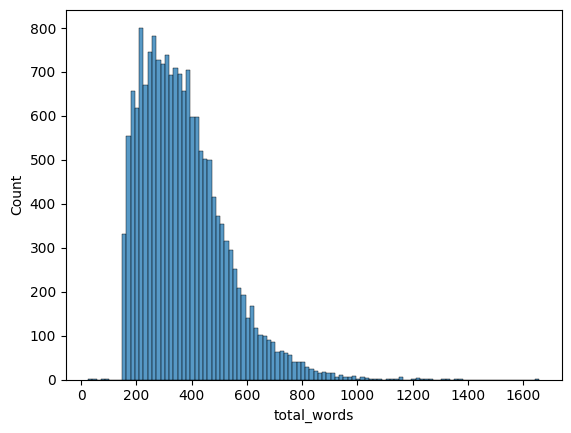

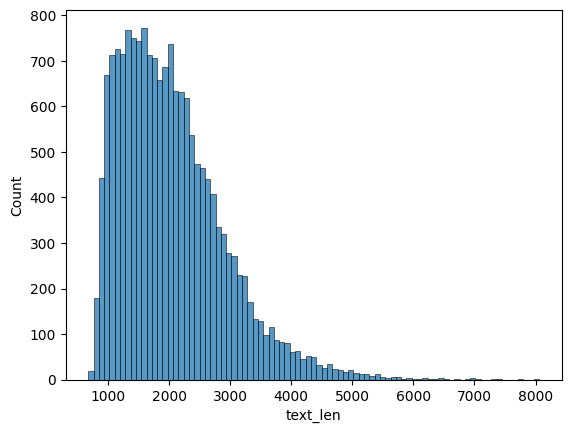

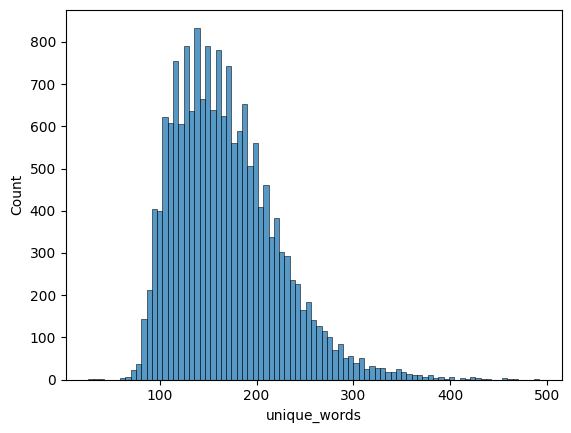

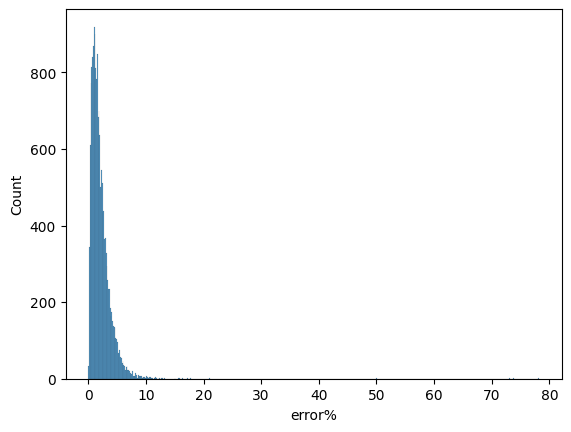

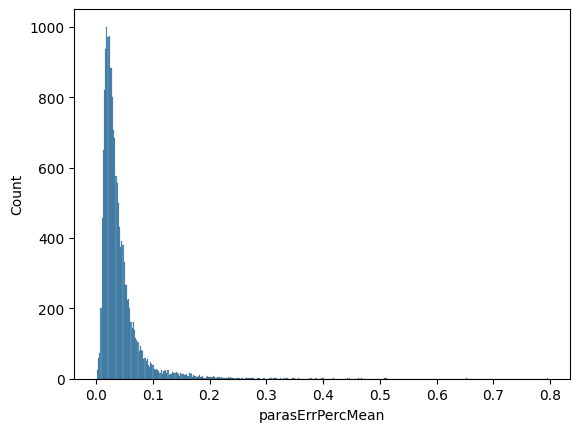

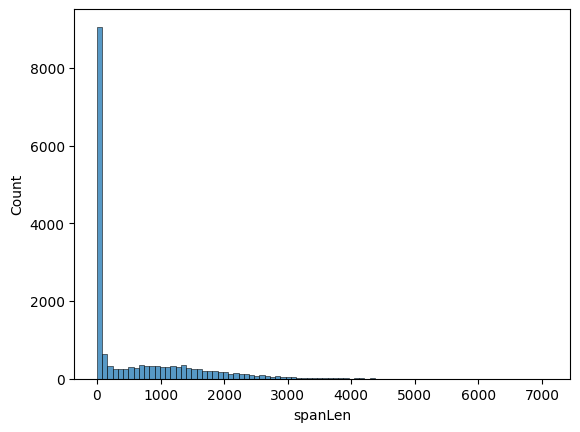

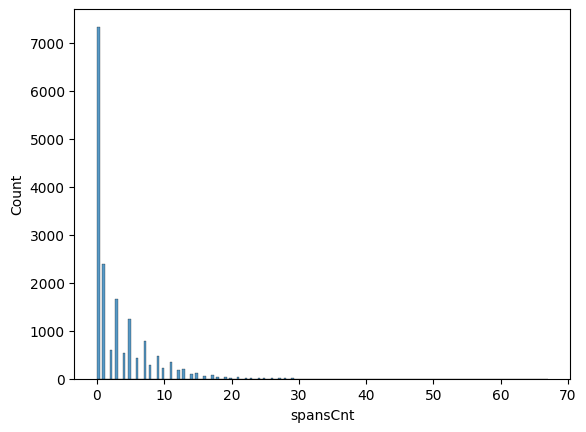

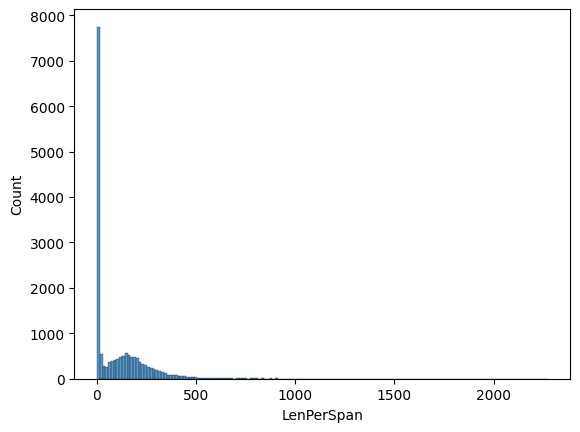

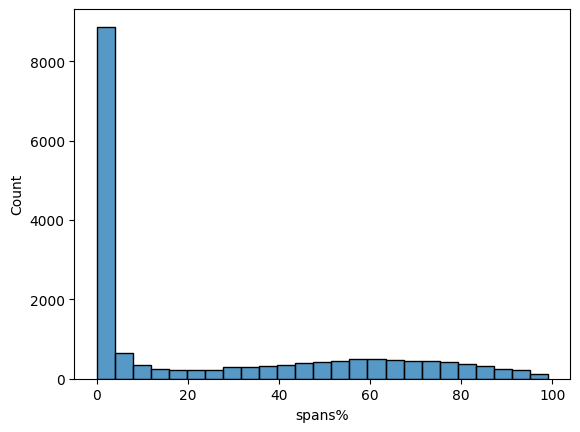

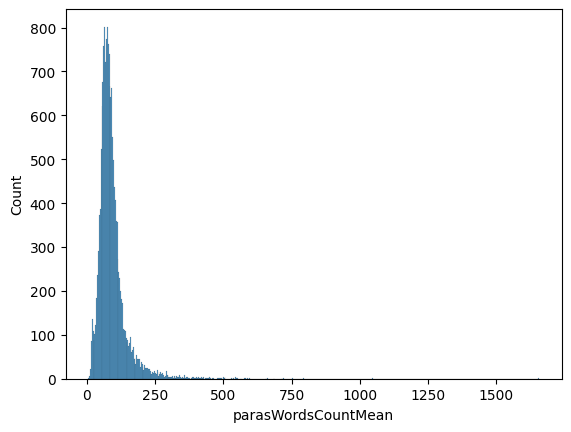

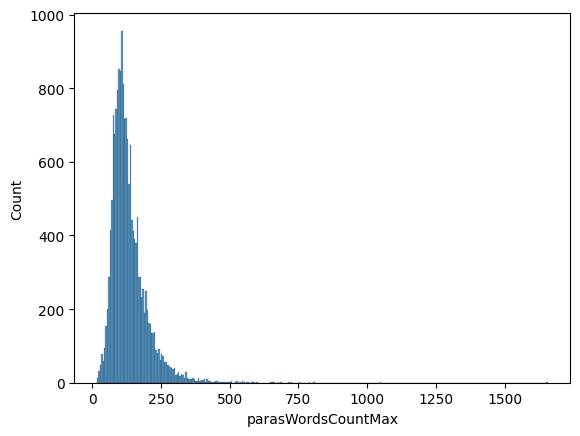

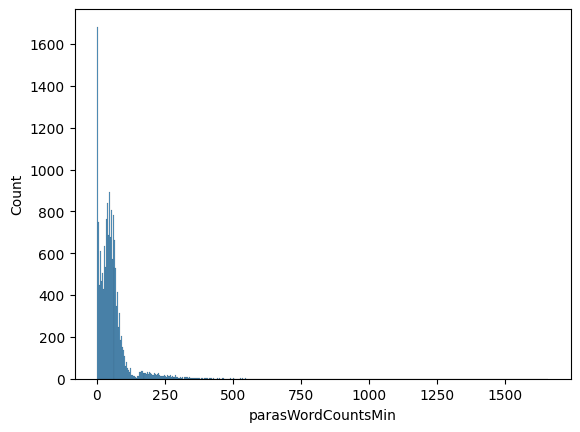

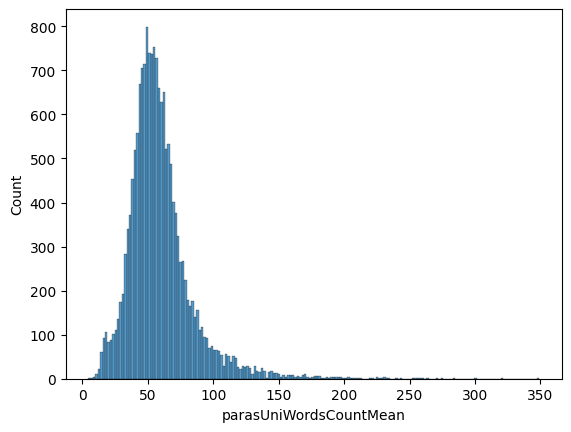

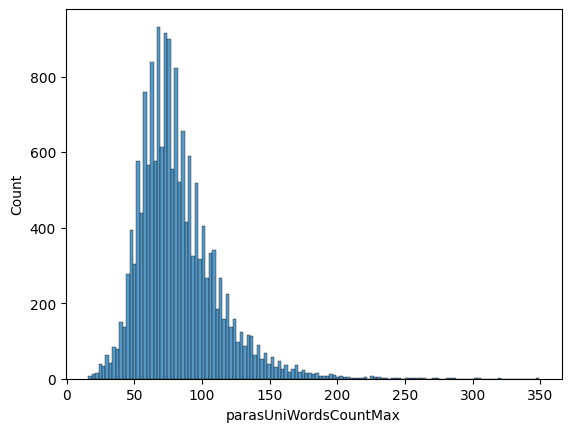

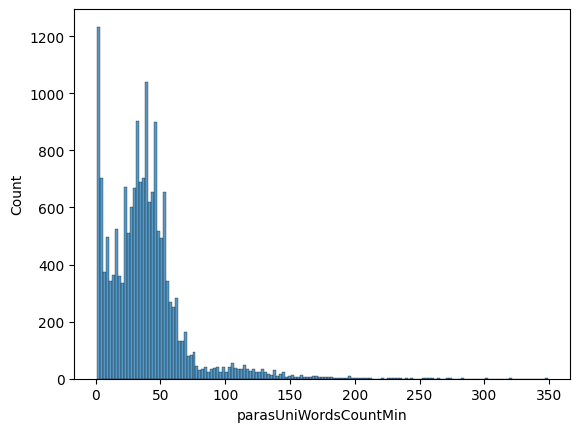

In [14]:
for col in binned_cols:
    sns.histplot(data=train, x=col)
    plt.show()

<div style="border-radius:10px; font-size:100%; padding:10px; color:#ffffff; background-color:#6827F5">

<h2 align="center"><font color="#ffffff">3.2 Feature Bins Dictionary</font></h2>
<a id="3.2"></a>

In [15]:
bins = {
    totalWords             : [200, 400, 600, 800],
    textLen                : [1000, 1800, 2600, 3400],
    uniqueWords            : [100, 150, 200, 250],
    errors                 : [2, 4, 6, 8],
    parasErrosPerc         : [.025, .05, .075, .1],
    spansLen               : [0, 800, 1600, 2400],
    spansCount             : [0, 4, 8, 13],
    lenPerSpan             : [0, 140, 280, 420],
    spansPerc              : [0, 25, 50, 75],
    parasWordsCountMean    : [60, 120, 180, 240],
    parasWordsCountMax     : [60, 120, 180, 240],
    parasWordCountsMin     : [10, 50, 100, 150],
    parasUniWordsCountMean : [25, 50, 75, 100],
    parasUniWordsCountMax  : [40, 80, 120, 160],
    parasUniWordsCountMin  : [10, 35, 60, 85]
}

In [16]:
def getGroupsList(data, col, count=5):
    """
    returns list of records of `count` groups of `col` column of `data` dataframe
    """
    grps = []
    for i in range(count):
        grps.append(data.filter(pl.col(col) == i)["score"])
    return grps

<div style="border-radius:10px; font-size:100%; padding:10px; color:#ffffff; background-color:#6827F5">

<h2 align="center"><font color="#ffffff">3.3 Statistical Utility Functions</font></h2>
<a id="3.3"></a>

Now I will create another set of **Utility Functions** but this time they will going to be help us in functionize our **Statistical Test's** requirements which includes fetching groups, performing normality and homogeneous test and apply relevant **Statistical Test**. 

In [17]:
# Statistical Tests and their functions

def andersonTest(data):
    results = anderson(data.to_numpy(), dist="norm")
    if results.statistic <= results.critical_values[2]:
        return True, results
    return False, results

def shapiroTest(data):
    results = shapiro(data)
    if results.pvalue > .05:
        return True, results
    return False, results 

def leveneTest(data, col, count):
    grps = getGroupsList(data, col, count=count)
    return levene(*grps)

def kruskalWallisTest(data, col, count):
    grps = getGroupsList(data, col, count=count)
    return kruskal(*grps) 

def anovaTest(data, col, var, count):
    grps = getGroupsList(data, col, count=count)
    return f_oneway(*grps, equal_var = var)

In [18]:
def getBins(df, col, LIST):
    """
    returns dataframe that has new column 'col'_BINNED that has groups based upon `LIST` values
    """
    
    assert len(LIST)==4, f"Length of List should be 4, but given list length is {len(LIST)}"

    def inner(x, vals = LIST):
        if x<=LIST[0]: return 0
        elif x<=LIST[1]: return 1
        elif x<=LIST[2]: return 2
        elif x<=LIST[3]: return 3
        else: return 4

    df = df.with_columns(pl.col(col).map_elements(inner, return_dtype = int).alias(f"{col}_BINNED"))
    return df

In [19]:
# Some utility functions for Printing Texts

def getColoredText(x, r=255, g=0, b=0):
    txt = f"\33[38;2;{r};{g};{b}m{x}\33[m"
    return txt


def printChar(char = "*", n=100):
    print(char*n)


def defineHypothesisText(col, target="score", count=5):
    print(f"H0: All groups of `{getColoredText(col, 255,255,)}` are statistically insignificant and they possess same mean `{target}`.")
    print()
    print(f"H1: There lies atleast one group in {getColoredText(col, 255,255)} whose mean `{target}` is statistically significant from all other groups.")
    printChar()


def defineHypothesisResultText(col, results):
    isSignificant = results.pvalue<.05
 
    if isSignificant:
        print(f"Groups of {col} are {getColoredText('STATISTICALLY SIGNIFICANT', 0, 255)} with P value {results.pvalue:.4f}, thus H0 is rejected.")
    else:
        print(f"Groups of {col} are not {getColoredText('STATISTICALLY SIGNIFICANT',)} with P value {results.pvalue:.4f}, thus H0 is not rejected.")
    printChar()
    return isSignificant


def testText(grp, cnt, flag, norm):
    if norm:
        normText = getColoredText("NORMAL", 0, 255,)
    else: 
        normText = getColoredText("NOT NORMAL")
        
    if flag: 
        print(f"On group {grp}({cnt}), We will use {getColoredText('Shapiro')} test, Found out it's {normText}")
    else: 
        print(f"On group {grp}({cnt}), We will use {getColoredText('Anderson-Darling', 0, 255, 0)} test, Found out it's {normText}")


_ = getColoredText("Demo")
print(getColoredText("This text will be Colored"))

This text will be Colored


In [20]:
# All selected columns will be binned into new columns

for col in bins.keys():
    train = getBins(train, col, bins[col])

In [21]:
def getGrpsCount(data, col):
    """
    Does mean of each group of column `col` of dataframe `data and
    Returns them as numpy array
    """
    return data.group_by([col]).agg(pl.col("score").count()).to_numpy()

In [22]:
def runNormalityTestOnGroups(data, col):
    grpsCount = getGrpsCount(data, col)
    NORMALS = 0
    results = {}
    
    for x in range(grpsCount.shape[0]):
        grp, cnt = grpsCount[x][0], grpsCount[x][1]
        flag = cnt<=5000
        
        if flag:
            normal, result = shapiroTest(data.filter(pl.col(col)==grp)["score"])
        else:
            normal, result = andersonTest(data.filter(pl.col(col)==grp)["score"])

        testText(grp, cnt, flag, normal)
        NORMALS += normal
        results[grp] = result
    printChar()

    return NORMALS == 5, results

In [23]:
def runVarianceTestOnGroups(data, col, count=5):
    print("Running Levene's test for homogeneity of Variance")
    printChar()
    results = leveneTest(data, col,count=count)
    variance = results.pvalue>.05
    printChar()
    if variance:
        print(f"Groups have {getColoredText('EQUAL VARIANCE', 0, 255)}, with P value {results.pvalue:.2f}")
    else:
        print(f"Groups have {getColoredText('UNEQUAL VARIANCE',)}, with P value {resuls.pvalue:.3f}")
    printChar()
        
    return variance, results

def runAnovaTestOnGroups(data, col, var=True, count=5):
    if var:
        print(f"Running {getColoredText('Standard ANOVA',)} test to check for statistical significance among groups")
    else: 
        print(f"Running {getColoredText('Welch ANOVA',)} test to check for statistical significance among groups")
    printChar()
    results = anovaTest(data, col, var, count=count)
    printChar()
    isSignificant = defineHypothesisResultText(col, results)
    printChar()
    return isSignificant, results

def runKruskalWallisTestOnGroups(data, col, count=5):
    print(f"Running {getColoredText('Kruskal Wallis', 0, 255)} test to check for statistical significance among groups")
    
    results = kruskalWallisTest(data, col,count=5)
    printChar()
    isSignificant = defineHypothesisResultText(col, results)
    printChar()
    return isSignificant, results

In [24]:
def runStatisticalTestOnGroups(data, col, target="score", count=5):
    """
    This functions will perform Hypothesis test on column `col`
    of dataframe `data` with group count `count`for mean of column `target` 
    Returns bool (statistical significance), TestResult
    """
    
    defineHypothesisText(col)
    n = 100
    isNormal, normResults = runNormalityTestOnGroups(train, col)

    if isNormal:

        print(f"All groups {col} are {getColoredText('NORMAL', 0, 255)}")
        printChar()
        
        isHomogeneous, varResults = runVarianceTestOnGroups(data, col )
        isSignificant, statsResults = runAnovaTestOnGroups(data, col, var=isHomogeneous, count=count)

    else:
        print(f"All groups of {col} are not {getColoredText('NOT NORMAL')}")
        printChar()
        isSignificant, statsResult = runKruskalWallisTestOnGroups(data, col, count=count) 

    return isSignificant, statsResult

In [25]:
# Calculating Cohen's Effect size (Both ETA and OMEGA Squared)

length = len(train)
grand_mean = train["score"].mean()
SST = np.sum((train["score"]-grand_mean).to_numpy()**2)

def getOmegaSquared(SSB, SST=SST,length=length, count=5):
    # Omega squared ω² for unequal grp size 
    df_between = count - 1
    df_within = length - count
    ms_within = (SST - SSB) / df_within

    return (SSB - (df_between * ms_within)) / (SST + ms_within)

def getEffect(value):
    if value <.01: return "NO EFFECT"
    if value < .06: return "SMALL EFFECT"
    elif value < .14: return "MEDIUM EFFECT" 
    else: return "LARGE EFFECT" # .14

def getEffectSize(data, col, SST=SST, grand_mean = grand_mean, count=5 ):
    grps = getGroupsList(data, col)

    # Sum of Squared Between (SSB)
    SSB = 0
    for grp in grps:
        SSB += (len(grp) * (grp.mean() - grand_mean)**2)

    # ETA squared, (η²)
    eta_squared = SSB / SST 
    omega_squared = getOmegaSquared(SSB)
    
    return eta_squared, getEffect(eta_squared), omega_squared, getEffect(omega_squared)

In [26]:
statisticalDict = {}

for col in bins.keys():
    
    statisticalDict[f"{col}_Significance"], statisticalDict[f"{col}_Result"] = runStatisticalTestOnGroups(train, f"{col}_BINNED", target="score", count=5)
    eta, etaEffect, omega, omegaEffect = getEffectSize(train, f"{col}_BINNED",)
    print(f"Cohen's Effect Size (Omega Squared): {getColoredText(f"{omega:.2f}", 0, 255)}, {getColoredText(omegaEffect, 0, 255)}")
    print()
    printChar(char="_")

H0: All groups of `total_words_BINNED` are statistically insignificant and they possess same mean `score`.

H1: There lies atleast one group in total_words_BINNED whose mean `score` is statistically significant from all other groups.
****************************************************************************************************
On group 3(1083), We will use Shapiro test, Found out it's NOT NORMAL
On group 0(1729), We will use Shapiro test, Found out it's NOT NORMAL
On group 1(9284), We will use Anderson-Darling test, Found out it's NOT NORMAL
On group 4(238), We will use Shapiro test, Found out it's NOT NORMAL
On group 2(4973), We will use Shapiro test, Found out it's NOT NORMAL
****************************************************************************************************
All groups of total_words_BINNED are not NOT NORMAL
****************************************************************************************************
Running Kruskal Wallis test to check for statistical 

In [27]:
statisticalDict

{'total_words_Significance': np.True_,
 'total_words_Result': KruskalResult(statistic=np.float64(7256.100633043384), pvalue=np.float64(0.0)),
 'text_len_Significance': np.True_,
 'text_len_Result': KruskalResult(statistic=np.float64(8152.377316043948), pvalue=np.float64(0.0)),
 'unique_words_Significance': np.True_,
 'unique_words_Result': KruskalResult(statistic=np.float64(6612.394358465757), pvalue=np.float64(0.0)),
 'error%_Significance': np.True_,
 'error%_Result': KruskalResult(statistic=np.float64(1327.7607431581089), pvalue=np.float64(3.1853817780290163e-286)),
 'parasErrPercMean_Significance': np.True_,
 'parasErrPercMean_Result': KruskalResult(statistic=np.float64(967.5138830558757), pvalue=np.float64(3.913395567263435e-208)),
 'spanLen_Significance': np.True_,
 'spanLen_Result': KruskalResult(statistic=np.float64(3061.7953364377995), pvalue=np.float64(0.0)),
 'spansCnt_Significance': np.True_,
 'spansCnt_Result': KruskalResult(statistic=np.float64(1918.4310723809888), pvalue=

In [28]:
# Dropping following columns as they are not needed anymore

to_drop = ['essay_id','full_text','text_cln',]
train = train.drop(to_drop)

In [29]:
NumLabels = train["score"].unique().count()
Labels = train["score"]
NumLabels

6

<div style="border-radius:10px; font-size:100%; padding:10px; color:#ffffff; background-color:#6827F5">

<h1 align="center"><font color="#ffffff">4. Predictive Modelling on Essay Scoring</font></h1>
<a id="4"></a>

Now that we know the statistical significance our our model and measured they real world application with **Cohen's Effect Size (Omega Squared)**, now I would like to develop **Predictive Modelling Pipeline** with which we can predict student's essay.

First I will test **Linear Predictive Models** and after that I will create **Tensorflow based Multi Layer Perceptron (MLP)**. Models will be evaluated with **Stratified KFold** on `Essay Score (y)` with **20%** size which ensures us that evaluation will include all the labels as they are distributed for training. Evaluation metrics is **Quadratic Weighted Kappa** also known as **Cohen Kappa Score** which penalized far away predictions more. 

In [30]:
from sklearn.linear_model import LinearRegression, Ridge, ElasticNet, Lasso, LogisticRegression, SGDClassifier
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)

In [31]:
# I will going to use Stratified CV strategy based upon Essay Scores

skf = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42) 

In [32]:
train = train.to_pandas()
train_copy = train.copy() 
scaled_train = train.copy()

<div style="border-radius:10px; font-size:100%; padding:10px; color:#ffffff; background-color:#6827F5">

<h2 align="center"><font color="#ffffff">4.1 Standard Scaling</font></h2>
<a id="4.3"></a>

Since we are utilizing **Linear Models and MLP**, all of this models perform well if data is standardized. For this reason I would use **Scikit Learn's Standard Scaler** for feature scaling.

In [33]:
# Scaling the dataset for SGD and Logistic Regression 

sc = StandardScaler() 

for col in scaled_train: 
    if col!="score": 
        scaled_train[col] = sc.fit_transform(scaled_train[col].values.reshape(-1, 1)).reshape(-1)

In [34]:
lr_preds = np.zeros(len(train))
en_preds = np.zeros(len(train))
lasso_preds = np.zeros(len(train))
ridge_preds = np.zeros(len(train))
logistic_preds = np.zeros(len(train))
logistic_probs = np.zeros((len(train), NumLabels))
sgd_preds = np.zeros(len(train))
svc_preds = np.zeros(len(train))

for tri, tsi in skf.split(X = train, y = train["score"]): 
    lr = LinearRegression(n_jobs=-1) 
    ridge = Ridge(alpha = 1.5,)
    en = ElasticNet() 
    lasso = Lasso()
    logistic = LogisticRegression(max_iter = 300, n_jobs=-1)
    sgd = SGDClassifier(loss = "log_loss", random_state = 42, n_jobs=-1)
    svc = SVC()

    lr.fit(
        X = scaled_train.drop("score", axis = 1).loc[tri],
        y = scaled_train["score"].loc[tri]
    )

    en.fit(
        X = train.drop("score", axis = 1).loc[tri],
        y = train["score"].loc[tri]
    )

    lasso.fit(
        X = train.drop("score", axis = 1).loc[tri],
        y = train["score"].loc[tri]
    )

    ridge.fit(
        X = scaled_train.drop("score", axis = 1).loc[tri],
        y = scaled_train["score"].loc[tri]
    )

    logistic.fit(
        X = scaled_train.drop("score", axis = 1).loc[tri],
        y = scaled_train["score"].loc[tri]
    )
    
    sgd.fit(
        X = scaled_train.drop("score", axis = 1).loc[tri],
        y = scaled_train["score"].loc[tri]
    )

    svc.fit(
        X = scaled_train.drop("score", axis = 1).loc[tri],
        y = scaled_train["score"].loc[tri]
    )

    lr_preds[tsi] = lr.predict(scaled_train.drop("score", axis = 1).loc[tsi])
    en_preds[tsi] = en.predict(train.drop("score", axis = 1).loc[tsi])
    lasso_preds[tsi] = lasso.predict(train.drop("score", axis = 1).loc[tsi])
    ridge_preds[tsi] = ridge.predict(scaled_train.drop("score", axis = 1).loc[tsi])
    logistic_preds[tsi] = logistic.predict(scaled_train.drop("score", axis = 1).loc[tsi])
    logistic_probs[tsi] = logistic.predict_proba(scaled_train.drop("score", axis = 1).loc[tsi])
    sgd_preds[tsi] = sgd.predict(scaled_train.drop("score", axis = 1).loc[tsi])
    svc_preds[tsi] = svc.predict(scaled_train.drop("score", axis = 1).loc[tsi])

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

In [35]:
from sklearn.metrics import cohen_kappa_score

lr_score = cohen_kappa_score(train["score"], lr_preds.clip(1, 6).round(), weights = "quadratic")
en_score = cohen_kappa_score(train["score"], en_preds.clip(1, 6).round(), weights = "quadratic")
lasso_score = cohen_kappa_score(train["score"], lasso_preds.clip(1, 6).round(), weights = "quadratic")
ridge_score = cohen_kappa_score(train["score"], ridge_preds.clip(1, 6).round(), weights = "quadratic")
logistic_score = cohen_kappa_score(train["score"], logistic_preds.clip(1, 6).round(), weights = "quadratic")
sgd_score = cohen_kappa_score(train["score"], sgd_preds.clip(1, 6).round(), weights = "quadratic")
svc_score = cohen_kappa_score(train["score"], svc_preds.clip(1, 6).round(), weights = "quadratic")

print(f"Linear Regression  : {lr_score:.3f}")
print(f"ElasticNet         : {en_score:.3f}")
print(f"Lasso Regression   : {lasso_score:.3f}")
print(f"Ridge Regression   : {ridge_score:.3f}")
print(f"Logistic Regression: {logistic_score:.3f}")
print(f"SGD Classifier     : {sgd_score:.3f}")
print(f"SVC                : {svc_score:.3f}")

Linear Regression  : 0.695
ElasticNet         : 0.665
Lasso Regression   : 0.662
Ridge Regression   : 0.696
Logistic Regression: 0.698
SGD Classifier     : 0.669
SVC                : 0.690


*********lr*********
*********en*********
*******lasso_*******
*******ridge********
******logistic******
********sgd*********
********svc*********


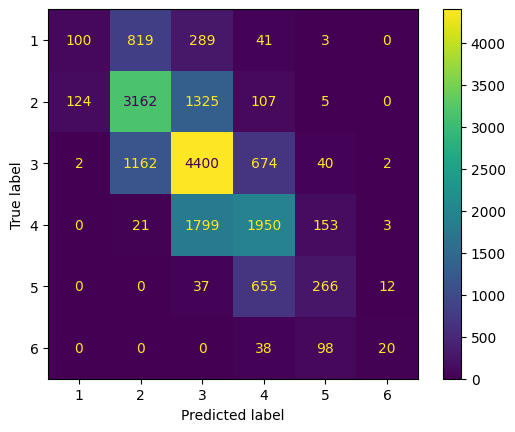

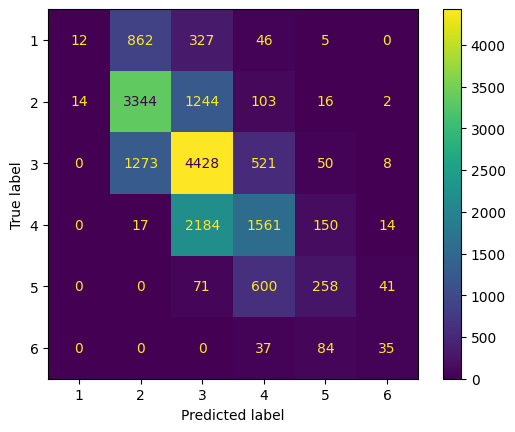

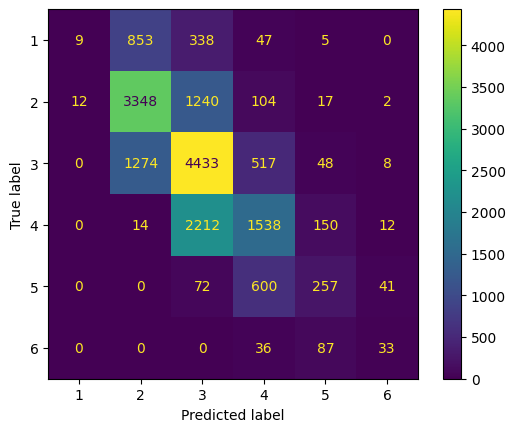

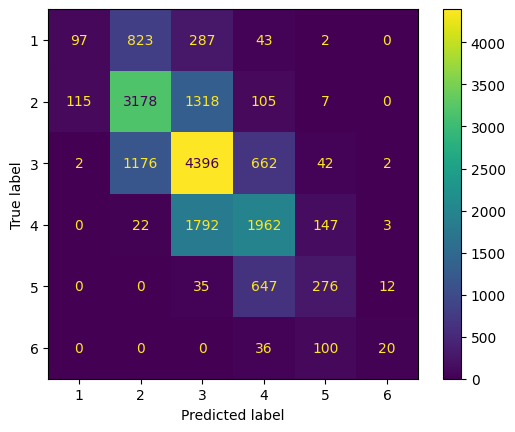

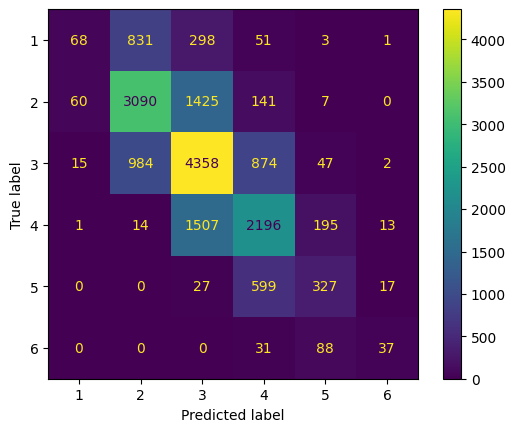

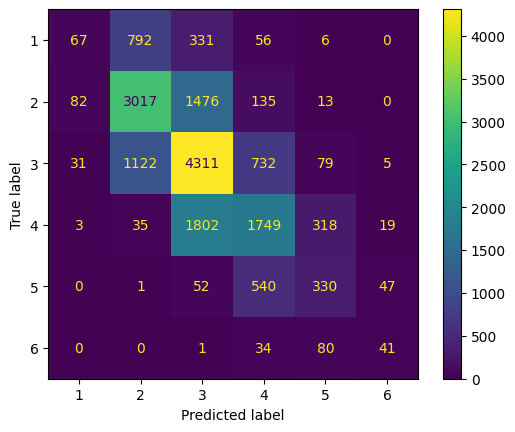

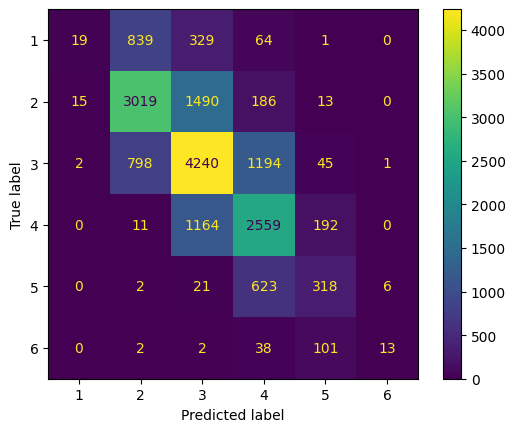

In [36]:
def displayConfusionMatrices(name, preds): 
    for n,p in zip(name, preds):
        p = p.clip(1,6).round() 
        print(f"{n:*^20}")
        ConfusionMatrixDisplay(
            confusion_matrix(train["score"], p, ),
            display_labels = [i for i in range(1, 7)]
        ).plot()
names = ["lr", "en", "lasso_", "ridge", "logistic", "sgd", "svc"]
preds = [lr_preds, en_preds, lasso_preds, ridge_preds, logistic_preds, sgd_preds, svc_preds]

displayConfusionMatrices(names, preds)

<div style="border-radius:10px; font-size:100%; padding:10px; color:#ffffff; background-color:#6827F5">

<h2 align="center"><font color="#ffffff">4.2 Optimizing our models with Thresholds Optimization</font></h2>
<a id="4.2"></a>

Now I will develop **Thresholds Optimization with Optuna** which is used in place of rounding off a prediction. Such thresholds when work provide very cheap way to optimize our models significantly as they are just used in place of rounding off which is computationally very cheap task as compared to other **Optimization Techniques** as I will develop them later on.

In [37]:
PREDS = {"preds": []}


def objective(trial): 
    a = trial.suggest_float("1", 1, 2)
    b = trial.suggest_float("2", 2, 3)
    c = trial.suggest_float("3", 3, 4)
    d = trial.suggest_float("4", 4, 5)
    e = trial.suggest_float("5", 5, 6)

    def cut(x, a=a,b=b,c=c,d=d,e=e): 
        if x<a: return 1
        elif x<b: return 2
        elif x<c: return 3
        elif x<d: return 4
        elif x<e: return 5
        else: return 6

    return cohen_kappa_score(train["score"], list(map(cut, PREDS["preds"])), weights = 'quadratic')

In [38]:
PREDS["preds"] = lr_preds
study = optuna.create_study(direction = "maximize") 
study.optimize(objective, n_trials = 300)

In [39]:
study.best_trial.value

0.7322868974385095

<div style="border-radius:10px; font-size:100%; padding:10px; color:#ffffff; background-color:#6827F5">

<h3 align="center"><font color="#ffffff">Threshold Optimization working like a Charm!</font></h3>

By applying **Threshold Optimization**, I have increased **QWK** from **0.695** to **0.732** which is **5%**. Thus proving my point of how powerful and cheap **Threshold Optimization** is.

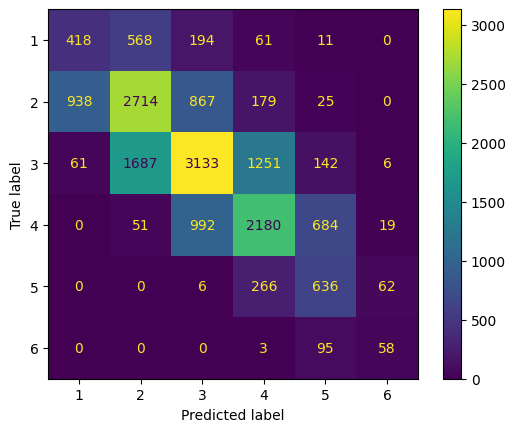

In [40]:
lr_th = study.best_params # lr_threholds

def cut(x, a=lr_th["1"],b=lr_th["2"],c=lr_th["3"],d=lr_th["4"],e=lr_th["5"]): 
        if x<a: return 1
        elif x<b: return 2
        elif x<c: return 3
        elif x<d: return 4
        elif x<e: return 5
        else: return 6


ConfusionMatrixDisplay(
            confusion_matrix(train["score"], list(map(cut, lr_preds)), ),
            display_labels = [i for i in range(1, 7)]
        ).plot()

<div style="border-radius:10px; font-size:100%; padding:10px; color:#ffffff; background-color:#6827F5">

<h2 align="center"><font color="#ffffff">4.3 Optimizing our models through Stacking</font></h2>
<a id="4.3"></a>

Another way to optimize our models is through Stacking one model with another by using prediction from model 1 as input feature for model 2. This enables model 2 to learn from the mistakes of model 1 and give enhanced predictions. 

Here I will use probabilities from **Logistic Regression** as input feature for our model 2 which is **Linear Regression**. Let's see whether we will going to observe any increase in **QWK** or not.

In [41]:
new = scaled_train.join(pd.DataFrame(data = logistic_probs, columns = [f"{i}" for i in range(1, 7)]))

lr_preds2 = np.zeros(len(train))

for tri, tsi in skf.split(X = new, y = new["score"]): 
    lr2 = LinearRegression() 

    lr2.fit(
        X = new.drop("score", axis = 1).loc[tri],
        y = new["score"].loc[tri]
    )

    lr_preds2[tsi] = lr2.predict(
        new.drop("score", axis = 1).loc[tsi])

In [42]:
# Comparing Simple LR and Stacking LR Scores

print(
    cohen_kappa_score(train["score"], lr_preds.clip(1, 6).round(), weights = "quadratic") * 100,
    cohen_kappa_score(train["score"], lr_preds2.clip(1, 6).round(), weights = "quadratic") * 100
)

69.49287498148801 70.00281818184688


<div style="border-radius:10px; font-size:100%; padding:10px; color:#ffffff; background-color:#6827F5">

<h3 align="center"><font color="#ffffff">Stacking Results</font></h3>

So by stacking **Logistic Regression** with **Linear Regression**, our **Linear Regression** improved from **.694** to **.7** which is **.7%** increase.

<div style="border-radius:10px; font-size:100%; padding:10px; color:#ffffff; background-color:#6827F5">

Now I would like to perform **Threshold Optimization** on **Stacking Models**. Usually 2 **Optimization Techniques** failed to bear strong results but let's try our luck.

In [43]:
n_trials = 400
PREDS["preds"] = lr_preds
study.optimize(objective, n_trials = n_trials)

print("Simple Linear Regression Threshold optimization", study.best_trial.value)

PREDS["preds"] = lr_preds2
study.optimize(objective, n_trials = n_trials)

print("Stacking Linear Regression Threshold optimization", study.best_trial.value)

Simple Linear Regression Threshold optimization 0.7325848608764789
Stacking Linear Regression Threshold optimization 0.7355038594681214


<div style="border-radius:10px; font-size:100%; padding:10px; color:#ffffff; background-color:#6827F5">

We did see some improvement but its very minimal **.4%**.

<div style="border-radius:10px; font-size:100%; padding:10px; color:#ffffff; background-color:#6827F5">

<h2 align="center"><font color="#ffffff">4.4 Tensorflow Based Multi Layer Perceptron (MLP)</font></h2>
<a id="4.4"></a>

Last thing that I would like to implement in this project is **Multi Layer Perceptron (MLP)**. **MLP** is very popular **Deep Neural Network (DNN)** and **Wide Neural Network (WNN)** and is capable in making all kind of predictions as well as in matrix reconstruction (Look at my Recommender Systems Notebook).

Here I will use **MLP** to test how better or worse it is in compared to **Linear Models**.

In [44]:
import tensorflow as tf 
from tensorflow.keras.layers import Input, Dropout, BatchNormalization, Activation, Dense, GaussianNoise
from tensorflow.keras.models import Model
from tensorflow.keras.losses import sparse_categorical_crossentropy
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping

In [45]:
num_features = len(train.columns)-1
neurons = [num_features, num_features*2, num_features*3, num_features*3, num_features*2]
dropouts = [.1, .15, .2, .2, .15]
epochs = 30

def createMLP(num_features, labels = 1,):
    _input = Input(shape = (num_features, )) 
    x = GaussianNoise(.08, seed = 42)(_input) 
    x = BatchNormalization()(x) 
    
    for i in range(5): 
        x = Dense(neurons[i])(x)
        x = Activation("swish")(x)
        x = BatchNormalization()(x)
        x = Dropout(dropouts[i])(x) 
    
    x = Dense(64)(x) 
    x = Activation("swish")(x)
    output = Dense(labels)(x)  
    
    model = Model(inputs = _input, outputs = output) 
    if labels==1:
        model.compile(
            loss = "mse", 
            optimizer = Adam(learning_rate = .001),
        ) 
    else: 
        model.compile(
            loss = sparse_categorical_crossentropy, 
            optimizer = Adam(learning_rate = .001),
        ) 
    
    return model

In [46]:
labels = 1

def getMLPPredictions(train, labels=1, batch_size = 256):
    num_features = len(train.columns)-1
    mlp_preds = np.zeros(len(train)) 
    
    for idx, (tri, tsi) in enumerate(skf.split(X = train, y = train["score"])): 
    
        ckpt = f"MLP_{idx}.weights.h5"
        
        rlr_cb = ReduceLROnPlateau(monitor = 'val_loss', factor = 0.5, patience = 4, verbose = 0, 
                                min_delta = 1e-4, mode = 'min')
        
        ckp_cb = ModelCheckpoint(ckpt, monitor = 'val_loss', verbose = 0, 
                               save_best_only = True, save_weights_only = True, mode = 'min')
        
        es_cb = EarlyStopping(monitor = 'val_loss', min_delta = 1e-4, patience = 6, mode = 'min', 
                           baseline = None, restore_best_weights = True, verbose = 0)
        
        model = createMLP(num_features = num_features)
        
        model.fit(
                x = train.drop("score", axis = 1).loc[tri],
                y = train["score"].loc[tri] + (0 if labels == 1 else -1),
            
            validation_data = (
                train.drop("score", axis = 1).loc[tri],
                train["score"].loc[tri] + (0 if labels == 1 else -1),
            ),
            
            batch_size = batch_size, 
            epochs = epochs, 
            callbacks = [rlr_cb, ckp_cb, es_cb], 
            verbose = 0
        )
    
        if labels == 1:
            mlp_preds[tsi] = model.predict(train.drop("score", axis = 1).loc[tsi]).reshape(-1)
        else: 
            mlp_preds[tsi] = model.predict(train.drop("score", axis = 1).loc[tsi]).argmax(-1).reshape(-1)

    return mlp_preds

mlp_preds = getMLPPredictions(scaled_train)

2026-09-11 05:53:06.381384: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [47]:
mlp_score = cohen_kappa_score(train["score"], mlp_preds.clip(1,6).round(), weights = "quadratic")
mlp_score

np.float64(0.7033405157583825)

<div style="border-radius:10px; font-size:100%; padding:10px; color:#ffffff; background-color:#6827F5">

<h3 align="center"><font color="#ffffff">MLP, Best Single Model</font></h3>

Among all the models that we have tested in this notebook till now, **MLP** (~**.707**) is top performant among all and is **1.2%** better than second best model which is **Logistic Regression** (**.698**).

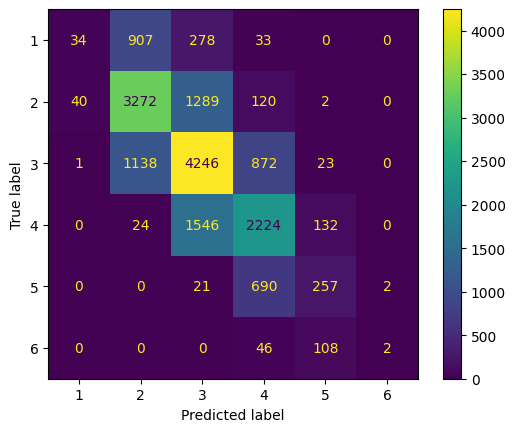

In [48]:
cm = confusion_matrix(train["score"], mlp_preds.clip(1,6).round())
ConfusionMatrixDisplay(cm, display_labels = [i for i in range(1, 7)]).plot()

In [49]:
names = ["lr", "en", "lasso", "ridge", "logistic", "sgd", "svc", "mlp",]
preds = [lr_score, en_score, lasso_score, ridge_score, logistic_score, sgd_score, svc_score, mlp_score,]

Text(0, 0.5, 'QWK Score')

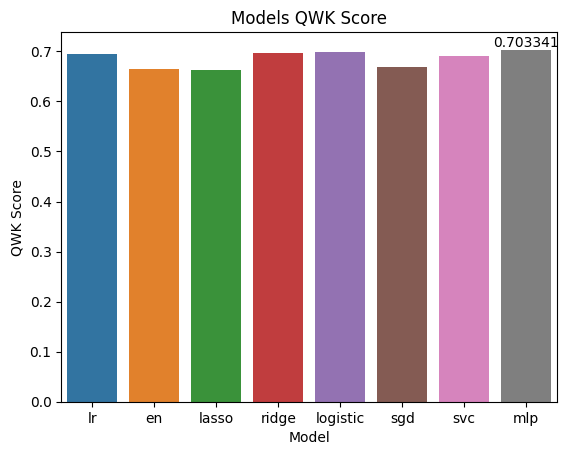

In [50]:
ax = sns.barplot(x = names, y = preds, hue = names)
ax.bar_label(ax.containers[np.argmax(preds)], fontsize=10)
ax.set_title("Models QWK Score")
ax.set_xlabel("Model")
ax.set_ylabel("QWK Score")

In [51]:
names = ["lr", "en", "lasso", "ridge", "mlp",]
models_score = [lr_score, en_score, lasso_score, ridge_score, mlp_score,]
models_preds = [lr_preds, en_preds, lasso_preds, ridge_preds, mlp_preds,]
optimized_scores = []
difference = []

<div style="border-radius:10px; font-size:100%; padding:10px; color:#ffffff; background-color:#6827F5">

Let's see how much increase or decrease in **QWK** score we get after performing **Threshold Optimization** on each model's prediction

In [52]:
for i, preds in enumerate(models_preds):
    PREDS["preds"] = preds
    study = optuna.create_study(direction = "maximize") 
    study.optimize(objective, n_trials = 300)
    optimized_scores.append(study.best_trial.value)
    difference.append(optimized_scores[-1]-models_score[i])

In [53]:
difference_perc = [d/s for s, d in  zip(models_score, difference)]
print(f"Average increase in each model's score after Threshold Optimization: {np.mean(difference_perc)*100:.2f}%")

Average increase in each model's score after Threshold Optimization: 5.67%


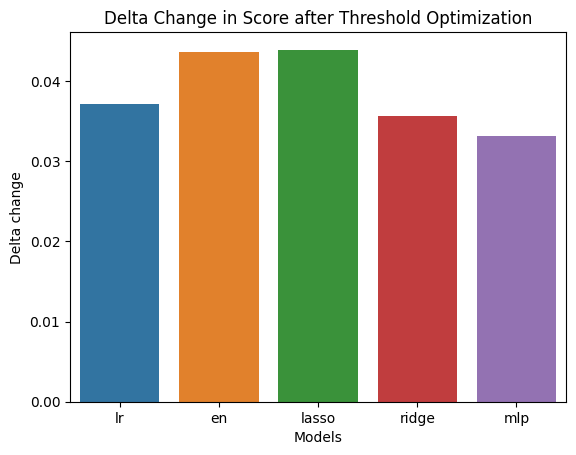

In [54]:
ax = sns.barplot(x = names, y = difference, hue = names)
ax.set_xlabel("Models")
ax.set_ylabel("Delta change")
ax.set_title("Delta Change in Score after Threshold Optimization")
plt.show()

<div style="border-radius:10px; font-size:100%; padding:10px; color:#ffffff; background-color:#6827F5">

<h3 align="center"><font color="#ffffff">Average Increase in QWK by Threshold Optimization</font></h3>

Each model is showing improvement in QWK score by atleast **3.7 (~5%)**.

<div style="border-radius:10px; font-size:100%; padding:10px; color:#ffffff; background-color:#6827F5">

<h1 align="center"><font color="#ffffff">5. Summary</font></h1>
<a id="5"></a>

This is the end of this **Hypothesis Testing** and **Predictive Modelling** on Essay Scoring dataset Notebook.

- Earlier I engineered some paragraph, sentences, words, errors and spans features with **Polars** to reduce **Feature Engineering** time.
- The I conducted **Hypothesis testing** on key features to check for their statistical significance.
- Then I created **Linear Models** to get some quick predictions.
- Found out that **Linear Regression**, **Logistic Regression** and **SVM** are strongest predictors.
- Stacking of **Logistic** with **Linear Regression** unable to increase score significantly.
- Then created **Multi Layer Perceptron** which is as powerful as linear models.
- After that implemented **Threshold Optimization** for regression models to generate optimized thresholds to split the labels and improved score of all the **Linear Models** and **MLP**.

<div style="border-radius:10px; font-size:100%; padding:10px; color:#ffffff; background-color:#6827F5">

<h2 align="center"><font color="#ffffff">THE END</font></h2>